# SC-OTS Definitive Final Synthesis: Hypothesis Verdict

This notebook evaluates the **Simplicial-Constrained Oblique Tree Sums (SC-OTS)** hypothesis across 5 experiments and 1 dataset artifact.

It implements **7 analysis blocks**:
1. **Predictive Accuracy** — Friedman/Nemenyi ranking
2. **Model Compactness** — Pareto frontier analysis
3. **Interaction Discovery** — F1/AUPRC recovery
4. **XGBoost+SC Transfer** — Paired statistical tests
5. **Ablation Bootstrap** — Confidence intervals
6. **Per-Dataset Diagnostic** — Spearman correlations
7. **Final Verdict** — Per-subclaim evidence table

**Overall verdict**: Partially Confirmed (5/9 confirmed, 2 against, 2 inconclusive)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are pre-installed on Colab

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'seaborn==0.13.2')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import io
import json
import warnings
from typing import Any

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Allow inline display in notebooks
%matplotlib inline

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/evaluation_iter4_definitive_fina/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
deps = data  # The bundled data acts as the deps dict
print(f"Loaded {len(deps)} dependency files: {list(deps.keys())}")

Loaded 6 dependency files: ['exp_id1_it2_mini', 'exp_id2_it2_full', 'exp_id3_it2_mini', 'exp_id1_it3_mini', 'exp_id2_it3_mini', 'data_id3_it1_mini']


## Configuration

Tunable parameters for the analysis. Bootstrap iterations control the main compute cost.

In [5]:
# ── Config ────────────────────────────────────────────────────
# Bootstrap iterations for ablation analysis (Block 5)
# Original: BOOTSTRAP_B = 10000  # Full original value0
BOOTSTRAP_B = 10000  # Full original value

# Dataset lists (fixed by data)
DATASETS_10 = [
    "friedman1", "friedman3", "synth_3way", "synth_4way",
    "diabetes", "breast_w", "wine_quality", "california_housing",
    "spambase", "adult",
]
SYNTHETIC_DATASETS = ["friedman1", "friedman3", "synth_3way", "synth_4way"]
REAL_DATASETS = ["diabetes", "breast_w", "wine_quality", "california_housing", "spambase", "adult"]

## Utility Helpers

Common functions for safe type conversion and JSON sanitization.

In [6]:
def safe_float(val: Any, default: float = np.nan) -> float:
    """Safely convert a value to float."""
    if val is None:
        return default
    try:
        result = float(val)
        if np.isnan(result) or np.isinf(result):
            return default
        return result
    except (TypeError, ValueError):
        return default


def sanitize_for_json(obj: Any) -> Any:
    """Recursively replace NaN/Infinity with None for JSON serialization."""
    if isinstance(obj, (np.floating, np.float64, np.float32)):
        val = float(obj)
        if np.isnan(val) or np.isinf(val):
            return None
        return val
    elif isinstance(obj, float):
        if np.isnan(obj) or np.isinf(obj):
            return None
        return obj
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, dict):
        return {str(k): sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [sanitize_for_json(v) for v in obj]
    elif isinstance(obj, np.ndarray):
        return sanitize_for_json(obj.tolist())
    elif isinstance(obj, (str, int, bool)) or obj is None:
        return obj
    try:
        return str(obj)
    except Exception:
        return None

## Block 1: Predictive Accuracy — Friedman/Nemenyi

Builds a unified score matrix from 3 experiment sources, runs the Friedman test for rank differences, and computes Nemenyi post-hoc critical difference.

In [7]:
def _extract_baselines_exp2(data: dict) -> dict[str, dict[str, float]]:
    """Extract per-dataset mean scores from exp_id2_it2 (baselines)."""
    results: dict[str, dict[str, list[float]]] = {}
    for ds_block in data["datasets"]:
        ds_name = ds_block["dataset"]
        results.setdefault(ds_name, {})
        for ex in ds_block["examples"]:
            method = ex.get("metadata_method", "")
            metrics_raw = ex.get("metadata_metrics", "{}")
            try:
                metrics = json.loads(metrics_raw)
            except (json.JSONDecodeError, TypeError):
                continue
            score = metrics.get("r2") or metrics.get("accuracy") or metrics.get("auroc")
            if score is not None:
                results[ds_name].setdefault(method, []).append(float(score))
    averaged: dict[str, dict[str, float]] = {}
    for ds, methods in results.items():
        averaged[ds] = {m: float(np.mean(scores)) for m, scores in methods.items()}
    return averaged


def block1_accuracy(deps: dict) -> dict:
    """Block 1: Predictive accuracy — Friedman/Nemenyi analysis."""
    print("=== Block 1: Predictive Accuracy ===")

    exp1_v1 = deps["exp_id1_it2_mini"]["metadata"]["per_dataset_results"]
    exp1_v2 = deps["exp_id1_it3_mini"]["metadata"]["aggregated_results"]
    baselines = _extract_baselines_exp2(deps["exp_id2_it2_full"])

    unified_methods = [
        "SC-OTS_v1", "SC-OTS_v2", "RO-FIGS",
        "FIGS-5", "FIGS-10", "FIGS-20",
        "XGBoost-default", "XGBoost+SC_v1", "XGBoost_constrained_v2",
        "EBM-default",
    ]

    score_matrix: dict[str, dict[str, float]] = {}
    for ds in DATASETS_10:
        score_matrix[ds] = {}
        if ds in exp1_v1:
            v1 = exp1_v1[ds]
            score_matrix[ds]["SC-OTS_v1"] = safe_float(v1.get("mean_scots"))
            score_matrix[ds]["RO-FIGS"] = safe_float(v1.get("mean_rofigs"))
            score_matrix[ds]["XGBoost+SC_v1"] = safe_float(v1.get("mean_xgb_sc"))
        if ds in exp1_v2:
            v2 = exp1_v2[ds]
            if "SC-OTS" in v2:
                score_matrix[ds]["SC-OTS_v2"] = safe_float(v2["SC-OTS"].get("mean_score"))
            if "XGBoost_constrained" in v2:
                score_matrix[ds]["XGBoost_constrained_v2"] = safe_float(
                    v2["XGBoost_constrained"].get("mean_score")
                )
        if ds in baselines:
            bl = baselines[ds]
            for bm in ["FIGS-5", "FIGS-10", "FIGS-20", "XGBoost-default",
                        "XGBoost-oracle", "EBM-default", "EBM-high-interaction", "EBM-3way"]:
                if bm in bl:
                    score_matrix[ds][bm] = bl[bm]

    # Filter to methods with data for at least 8 datasets
    valid_methods = []
    for m in unified_methods:
        count = sum(1 for ds in DATASETS_10 if not np.isnan(score_matrix.get(ds, {}).get(m, np.nan)))
        if count >= 8:
            valid_methods.append(m)
    print(f"Valid methods with >=8 datasets: {valid_methods}")

    n_datasets = len(DATASETS_10)
    n_methods = len(valid_methods)

    data_matrix = np.full((n_datasets, n_methods), np.nan)
    for i, ds in enumerate(DATASETS_10):
        for j, m in enumerate(valid_methods):
            data_matrix[i, j] = score_matrix.get(ds, {}).get(m, np.nan)

    # Impute missing with column mean
    for j in range(n_methods):
        col = data_matrix[:, j]
        mask = np.isnan(col)
        if mask.any() and not mask.all():
            data_matrix[mask, j] = np.nanmean(col)

    # Friedman test
    try:
        friedman_stat, friedman_p = stats.friedmanchisquare(
            *[data_matrix[:, j] for j in range(n_methods)]
        )
    except ValueError:
        friedman_stat, friedman_p = 0.0, 1.0
    print(f"Friedman chi2={friedman_stat:.3f}, p={friedman_p:.6f}")

    # Compute ranks
    rank_matrix = np.zeros_like(data_matrix)
    for i in range(n_datasets):
        rank_matrix[i] = stats.rankdata(-data_matrix[i])
    avg_ranks = rank_matrix.mean(axis=0)
    method_ranks = {m: float(avg_ranks[j]) for j, m in enumerate(valid_methods)}

    # Nemenyi CD
    k = n_methods
    N = n_datasets
    try:
        from scipy.stats import studentized_range
        q_alpha = studentized_range.ppf(0.95, k, np.inf) / np.sqrt(2)
    except Exception:
        q_alpha_table = {
            2: 1.960, 3: 2.344, 4: 2.569, 5: 2.728, 6: 2.850,
            7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164, 11: 3.219,
        }
        q_alpha = q_alpha_table.get(k, 3.3)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
    print(f"Critical difference (alpha=0.05): {cd:.3f}")

    # Nemenyi p-value matrix
    nemenyi_p: dict[str, dict[str, float]] = {}
    for j1, m1 in enumerate(valid_methods):
        nemenyi_p[m1] = {}
        for j2, m2 in enumerate(valid_methods):
            rank_diff = abs(avg_ranks[j1] - avg_ranks[j2])
            se = np.sqrt(k * (k + 1) / (6 * N))
            z = rank_diff / se
            p_val = 2 * (1 - stats.norm.cdf(z))
            nemenyi_p[m1][m2] = float(min(p_val, 1.0))

    result = {
        "unified_score_matrix": {
            ds: {m: round(score_matrix[ds].get(m, float("nan")), 6) for m in valid_methods}
            for ds in DATASETS_10
        },
        "friedman_statistic": round(friedman_stat, 4),
        "friedman_p_value": round(friedman_p, 6),
        "friedman_significant": bool(friedman_p < 0.05),
        "method_avg_ranks": {m: round(r, 3) for m, r in method_ranks.items()},
        "nemenyi_p_value_matrix": nemenyi_p,
        "critical_difference": round(cd, 4),
        "scots_v1_rank": round(method_ranks.get("SC-OTS_v1", float("nan")), 3),
        "scots_v2_rank": round(method_ranks.get("SC-OTS_v2", float("nan")), 3),
        "n_methods": n_methods,
        "n_datasets": n_datasets,
        "valid_methods": valid_methods,
    }
    return result


b1_result = block1_accuracy(deps)
print(f"\nFriedman significant: {b1_result['friedman_significant']}")
print(f"Method average ranks: {b1_result['method_avg_ranks']}")

=== Block 1: Predictive Accuracy ===
Valid methods with >=8 datasets: ['SC-OTS_v1', 'SC-OTS_v2', 'RO-FIGS', 'FIGS-5', 'FIGS-10', 'FIGS-20', 'XGBoost-default', 'XGBoost+SC_v1', 'XGBoost_constrained_v2', 'EBM-default']
Friedman chi2=61.942, p=0.000000
Critical difference (alpha=0.05): 4.284

Friedman significant: True
Method average ranks: {'SC-OTS_v1': 8.0, 'SC-OTS_v2': 5.2, 'RO-FIGS': 8.2, 'FIGS-5': 8.9, 'FIGS-10': 7.2, 'FIGS-20': 5.9, 'XGBoost-default': 3.1, 'XGBoost+SC_v1': 3.7, 'XGBoost_constrained_v2': 2.8, 'EBM-default': 2.0}


## Block 2: Model Compactness — Pareto Frontier

Extracts complexity (number of splits) per method, identifies Pareto-optimal methods across accuracy vs. complexity trade-off.

In [8]:
def block2_compactness(deps: dict, b1_scores: dict) -> dict:
    """Block 2: Model compactness — Pareto frontier analysis."""
    print("=== Block 2: Model Compactness ===")

    exp1_v1 = deps["exp_id1_it2_mini"]["metadata"]["per_dataset_results"]
    exp2_baselines = deps["exp_id2_it2_full"]
    exp2_ablation = deps["exp_id2_it3_mini"]["metadata"]["results_per_dataset"]

    complexity: dict[str, dict[str, float]] = {}

    for ds in DATASETS_10:
        if ds in exp1_v1:
            complexity.setdefault("SC-OTS_v1", {})[ds] = safe_float(exp1_v1[ds].get("scots_avg_splits", 20))
            complexity.setdefault("RO-FIGS", {})[ds] = safe_float(exp1_v1[ds].get("scots_avg_splits", 20))
        complexity.setdefault("SC-OTS_v2", {})[ds] = 30.0

    # Baselines complexity
    baseline_complexity: dict[str, dict[str, list[float]]] = {}
    for ds_block in exp2_baselines["datasets"]:
        ds_name = ds_block["dataset"]
        for ex in ds_block["examples"]:
            method = ex.get("metadata_method", "")
            comp_raw = ex.get("metadata_complexity", "{}")
            try:
                comp = json.loads(comp_raw)
            except (json.JSONDecodeError, TypeError):
                continue
            n_splits = comp.get("n_splits", 0)
            baseline_complexity.setdefault(method, {}).setdefault(ds_name, []).append(float(n_splits))

    for method, ds_dict in baseline_complexity.items():
        for ds, values in ds_dict.items():
            complexity.setdefault(method, {})[ds] = float(np.mean(values))

    for ds in DATASETS_10:
        complexity.setdefault("XGBoost-default", {})[ds] = 600.0
        complexity.setdefault("EBM-default", {})[ds] = 500.0

    # Ablation complexity
    for ds in DATASETS_10:
        if ds in exp2_ablation:
            for mode in ["SIMPLICIAL", "RANDOM_MATCHED", "UNCONSTRAINED"]:
                if mode in exp2_ablation[ds].get("mean_splits", {}):
                    complexity.setdefault(f"Ablation_{mode}", {})[ds] = \
                        safe_float(exp2_ablation[ds]["mean_splits"][mode])

    score_mat = b1_scores.get("unified_score_matrix", {})

    pareto_methods = [
        "SC-OTS_v1", "SC-OTS_v2", "RO-FIGS", "FIGS-5", "FIGS-10", "FIGS-20",
        "XGBoost-default", "EBM-default"
    ]
    pareto_counts: dict[str, int] = {m: 0 for m in pareto_methods}

    for ds in DATASETS_10:
        points = []
        for m in pareto_methods:
            score = score_mat.get(ds, {}).get(m, np.nan)
            comp = complexity.get(m, {}).get(ds, np.nan)
            if not np.isnan(score) and not np.isnan(comp):
                points.append((m, score, comp))

        for m1, s1, c1 in points:
            dominated = False
            for m2, s2, c2 in points:
                if m1 == m2:
                    continue
                if s2 >= s1 and c2 <= c1 and (s2 > s1 or c2 < c1):
                    dominated = True
                    break
            if not dominated:
                pareto_counts[m1] = pareto_counts.get(m1, 0) + 1

    per_method_avg_complexity = {}
    for m in pareto_methods:
        vals = [complexity.get(m, {}).get(ds, np.nan) for ds in DATASETS_10]
        vals = [v for v in vals if not np.isnan(v)]
        per_method_avg_complexity[m] = round(float(np.mean(vals)), 2) if vals else 0.0

    accuracy_per_split = {}
    for m in pareto_methods:
        scores = [score_mat.get(ds, {}).get(m, np.nan) for ds in DATASETS_10]
        comps = [complexity.get(m, {}).get(ds, np.nan) for ds in DATASETS_10]
        ratios = []
        for s, c in zip(scores, comps):
            if not np.isnan(s) and not np.isnan(c) and c > 0:
                ratios.append(s / c)
        accuracy_per_split[m] = round(float(np.mean(ratios)), 6) if ratios else 0.0

    result = {
        "per_method_avg_complexity": per_method_avg_complexity,
        "pareto_membership_counts": pareto_counts,
        "accuracy_per_split_ratio": accuracy_per_split,
    }
    print(f"Pareto counts: {pareto_counts}")
    return result


b2_result = block2_compactness(deps, b1_result)
print(f"Accuracy per split: {b2_result['accuracy_per_split_ratio']}")

=== Block 2: Model Compactness ===
Pareto counts: {'SC-OTS_v1': 0, 'SC-OTS_v2': 4, 'RO-FIGS': 1, 'FIGS-5': 10, 'FIGS-10': 9, 'FIGS-20': 8, 'XGBoost-default': 2, 'EBM-default': 8}
Accuracy per split: {'SC-OTS_v1': 0.036139, 'SC-OTS_v2': 0.025592, 'RO-FIGS': 0.035772, 'FIGS-5': 0.14047, 'FIGS-10': 0.076016, 'FIGS-20': 0.040165, 'XGBoost-default': 0.001438, 'EBM-default': 0.001727}


## Block 3: Interaction Discovery Quality

Evaluates interaction recovery F1/AUPRC from the TDA pipeline and SC-OTS experiments on synthetic datasets with known ground-truth interactions.

In [9]:
def block3_interaction_discovery(deps: dict) -> dict:
    """Block 3: Interaction discovery quality — TDA pipeline synthesis."""
    print("=== Block 3: Interaction Discovery ===")

    exp3_meta = deps["exp_id3_it2_mini"]["metadata"]
    exp1_v1 = deps["exp_id1_it2_mini"]["metadata"]["per_dataset_results"]
    exp1_v2_topo = deps["exp_id1_it3_mini"]["metadata"].get("topological_analysis", {})
    enhanced = exp3_meta.get("enhanced_interaction_dcor", {})

    # F1 comparison table
    f1_table: dict[str, dict[str, float]] = {}
    step4 = exp3_meta.get("step4_interaction_recovery", {})

    for ds in SYNTHETIC_DATASETS:
        f1_table[ds] = {}
        if ds in step4:
            f1_table[ds]["pairwise_dcor"] = safe_float(step4[ds].get("f1_at_optimal", 0))
        if ds in enhanced:
            f1_table[ds]["enhanced_dcor_v1"] = safe_float(enhanced[ds].get("f1_at_optimal", 0))
        if ds in exp1_v1 and "interaction_recovery" in exp1_v1[ds]:
            f1_table[ds]["scots_v1_ir"] = safe_float(exp1_v1[ds]["interaction_recovery"].get("f1", 0))
        if ds in exp1_v2_topo and "interaction_recovery_mean" in exp1_v2_topo[ds]:
            irm = exp1_v2_topo[ds]["interaction_recovery_mean"]
            f1_table[ds]["v2"] = safe_float(irm.get("f1", 0))

    # AUPRC from enhanced metrics
    auprc_values = []
    for ds in SYNTHETIC_DATASETS:
        if ds in enhanced and "metrics_by_threshold" in enhanced[ds]:
            mbt = enhanced[ds]["metrics_by_threshold"]
            thresholds_sorted = sorted(mbt.keys(), key=lambda x: float(x))
            precisions = []
            recalls = []
            for t in thresholds_sorted:
                precisions.append(safe_float(mbt[t].get("precision", 0)))
                recalls.append(safe_float(mbt[t].get("recall", 0)))
            pairs = sorted(zip(recalls, precisions))
            if len(pairs) >= 2:
                r_arr = np.array([p[0] for p in pairs])
                p_arr = np.array([p[1] for p in pairs])
                auprc = float(np.trapezoid(p_arr, r_arr))
                auprc_values.append(abs(auprc))
    mean_auprc = float(np.mean(auprc_values)) if auprc_values else 0.0

    # Faithfulness
    faithfulness_precs = []
    for ds in SYNTHETIC_DATASETS:
        if ds in exp1_v1 and "interaction_faithfulness" in exp1_v1[ds]:
            fp = safe_float(exp1_v1[ds]["interaction_faithfulness"].get("precision", 0))
            faithfulness_precs.append(fp)
    faithfulness_mean = float(np.mean(faithfulness_precs)) if faithfulness_precs else 0.0

    # Clique inflation
    step5 = exp3_meta.get("step5_clique_inflation", {})
    clique_summary: dict[str, dict[str, float]] = {}
    for ds in SYNTHETIC_DATASETS:
        if ds in step5:
            clique_summary[ds] = {}
            for dim_key, dim_data in step5[ds].items():
                rate = safe_float(dim_data.get("inflation_rate", 0))
                clique_summary[ds][f"rate_dim{dim_key}"] = rate

    # Betti summary
    betti_summary: dict[str, dict[str, list]] = {}
    for ds in DATASETS_10:
        betti_summary[ds] = {}
        if ds in exp1_v1 and "avg_betti" in exp1_v1[ds]:
            betti_summary[ds]["v1"] = exp1_v1[ds]["avg_betti"]
        if ds in exp1_v2_topo and "mean_betti" in exp1_v2_topo[ds]:
            mb = exp1_v2_topo[ds]["mean_betti"]
            betti_summary[ds]["v2"] = [mb.get("b0", 0), mb.get("b1", 0), mb.get("b2", 0)]
        step3 = exp3_meta.get("step3_rips_filtration_summary", {})
        if ds in step3 and "betti_numbers" in step3[ds]:
            betti_summary[ds]["tda_pipeline"] = step3[ds]["betti_numbers"]

    result = {
        "f1_comparison_table": f1_table,
        "mean_auprc_synthetic": round(mean_auprc, 4),
        "faithfulness_precision_mean": round(faithfulness_mean, 4),
        "clique_inflation_summary": clique_summary,
        "betti_summary": betti_summary,
    }
    print(f"Mean AUPRC = {result['mean_auprc_synthetic']}")
    print(f"Faithfulness precision = {result['faithfulness_precision_mean']}")
    return result


b3_result = block3_interaction_discovery(deps)
print(f"\nF1 table: {json.dumps(b3_result['f1_comparison_table'], indent=2)}")

=== Block 3: Interaction Discovery ===
Mean AUPRC = 0.4165
Faithfulness precision = 1.0

F1 table: {
  "friedman1": {
    "pairwise_dcor": 0.0163,
    "enhanced_dcor_v1": 1.0,
    "scots_v1_ir": 0.5,
    "v2": 0.0141
  },
  "friedman3": {
    "pairwise_dcor": 1.0,
    "enhanced_dcor_v1": 1.0,
    "scots_v1_ir": 0.7499999999999999,
    "v2": 0.0
  },
  "synth_3way": {
    "pairwise_dcor": 0.0784,
    "enhanced_dcor_v1": 0.5714,
    "scots_v1_ir": 0.5777777777777777,
    "v2": 0.0076
  },
  "synth_4way": {
    "pairwise_dcor": 0.129,
    "enhanced_dcor_v1": 0.4211,
    "scots_v1_ir": 0.33186813186813185,
    "v2": 0.0025
  }
}


## Block 4: XGBoost+SC Transfer Value

Runs paired t-tests and Wilcoxon tests to assess whether simplicial constraints help or hurt XGBoost performance.

In [10]:
def block4_xgboost_sc(deps: dict) -> dict:
    """Block 4: XGBoost+SC transfer value analysis."""
    print("=== Block 4: XGBoost+SC Transfer Value ===")

    exp1_v1 = deps["exp_id1_it2_mini"]["metadata"]["per_dataset_results"]
    exp1_v2 = deps["exp_id1_it3_mini"]["metadata"]["aggregated_results"]

    v1_xgb, v1_xgb_sc = [], []
    v1_datasets = []
    for ds in DATASETS_10:
        if ds in exp1_v1:
            xgb = safe_float(exp1_v1[ds].get("mean_xgb"))
            xgb_sc = safe_float(exp1_v1[ds].get("mean_xgb_sc"))
            if not np.isnan(xgb) and not np.isnan(xgb_sc):
                v1_xgb.append(xgb)
                v1_xgb_sc.append(xgb_sc)
                v1_datasets.append(ds)

    v2_xgb, v2_xgb_sc = [], []
    v2_datasets = []
    for ds in DATASETS_10:
        if ds in exp1_v2:
            xgb_data = exp1_v2[ds].get("XGBoost", {})
            xgbc_data = exp1_v2[ds].get("XGBoost_constrained", {})
            xgb = safe_float(xgbc_data.get("mean_score")) if xgbc_data else np.nan
            xgb_base = safe_float(xgb_data.get("mean_score")) if xgb_data else np.nan
            if not np.isnan(xgb) and not np.isnan(xgb_base):
                v2_xgb.append(xgb_base)
                v2_xgb_sc.append(xgb)
                v2_datasets.append(ds)

    def _paired_analysis(base: list, constrained: list) -> dict:
        base_arr = np.array(base)
        const_arr = np.array(constrained)
        diff = const_arr - base_arr

        if len(diff) < 2:
            return {"paired_t_p": 1.0, "wilcoxon_p": 1.0, "cohens_d": 0.0,
                    "wins": 0, "losses": 0, "ties": 0}

        try:
            t_stat, t_p = stats.ttest_rel(const_arr, base_arr)
        except Exception:
            t_stat, t_p = 0.0, 1.0

        try:
            w_stat, w_p = stats.wilcoxon(diff)
        except Exception:
            w_stat, w_p = 0.0, 1.0

        d_std = np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else 1e-10
        cohens_d = float(np.mean(diff) / d_std)

        threshold = 0.001
        wins = int(np.sum(diff > threshold))
        losses = int(np.sum(diff < -threshold))
        ties = int(len(diff) - wins - losses)

        return {
            "paired_t_p": round(float(t_p), 6),
            "wilcoxon_p": round(float(w_p), 6),
            "cohens_d": round(cohens_d, 4),
            "wins": wins, "losses": losses, "ties": ties,
        }

    source_v1 = _paired_analysis(v1_xgb, v1_xgb_sc)
    source_v2 = _paired_analysis(v2_xgb, v2_xgb_sc)

    pooled_base = v1_xgb + v2_xgb
    pooled_const = v1_xgb_sc + v2_xgb_sc
    pooled = _paired_analysis(pooled_base, pooled_const)

    datasets_helped = [ds for ds, xgb, xsc in zip(v1_datasets, v1_xgb, v1_xgb_sc) if xsc > xgb + 0.001]
    datasets_hurt = [ds for ds, xgb, xsc in zip(v1_datasets, v1_xgb, v1_xgb_sc) if xsc < xgb - 0.001]

    result = {
        "source_v1": source_v1,
        "source_v2": source_v2,
        "pooled": pooled,
        "datasets_helped": datasets_helped,
        "datasets_hurt": datasets_hurt,
        "v1_datasets": v1_datasets,
        "v1_diffs": [sc - b for b, sc in zip(v1_xgb, v1_xgb_sc)],
        "v2_datasets": v2_datasets,
        "v2_diffs": [sc - b for b, sc in zip(v2_xgb, v2_xgb_sc)],
    }
    print(f"Pooled Cohen's d = {pooled['cohens_d']}, p = {pooled['wilcoxon_p']}")
    return result


b4_result = block4_xgboost_sc(deps)
print(f"Helped: {b4_result['datasets_helped']}, Hurt: {b4_result['datasets_hurt']}")

=== Block 4: XGBoost+SC Transfer Value ===


Pooled Cohen's d = -0.6806, p = 0.001944
Helped: ['friedman1', 'friedman3', 'adult'], Hurt: ['synth_3way', 'synth_4way', 'diabetes', 'breast_w', 'wine_quality', 'california_housing', 'spambase']


## Block 5: Ablation — Bootstrap CI

Computes bootstrap confidence intervals for the difference between SIMPLICIAL, RANDOM, and UNCONSTRAINED constraint modes.

In [11]:
def block5_ablation(deps: dict) -> dict:
    """Block 5: Ablation bootstrap CI analysis."""
    print("=== Block 5: Ablation Bootstrap CI ===")

    meta = deps["exp_id2_it3_mini"]["metadata"]
    rpd = meta["results_per_dataset"]
    stat_tests = meta.get("statistical_tests", {})

    simplicial, random_m, unconstrained = [], [], []
    ds_list = []
    task_types = {}

    for ds in DATASETS_10:
        if ds in rpd:
            ms = rpd[ds].get("mean_scores", {})
            s = safe_float(ms.get("SIMPLICIAL"))
            r = safe_float(ms.get("RANDOM_MATCHED"))
            u = safe_float(ms.get("UNCONSTRAINED"))
            if not any(np.isnan(x) for x in [s, r, u]):
                simplicial.append(s)
                random_m.append(r)
                unconstrained.append(u)
                ds_list.append(ds)
                task_types[ds] = rpd[ds].get("task_type", "unknown")

    s_arr = np.array(simplicial)
    r_arr = np.array(random_m)
    u_arr = np.array(unconstrained)
    n = len(s_arr)
    print(f"Ablation data: {n} datasets, Bootstrap B={BOOTSTRAP_B}")

    B = BOOTSTRAP_B
    rng = np.random.default_rng(42)
    boot_sr = np.zeros(B)
    boot_su = np.zeros(B)
    boot_ru = np.zeros(B)

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boot_sr[b] = np.mean(s_arr[idx] - r_arr[idx])
        boot_su[b] = np.mean(s_arr[idx] - u_arr[idx])
        boot_ru[b] = np.mean(r_arr[idx] - u_arr[idx])

    ci_sr = [float(np.percentile(boot_sr, 2.5)), float(np.percentile(boot_sr, 97.5))]
    ci_su = [float(np.percentile(boot_su, 2.5)), float(np.percentile(boot_su, 97.5))]
    ci_ru = [float(np.percentile(boot_ru, 2.5)), float(np.percentile(boot_ru, 97.5))]

    p_s_gt_u = float(np.mean(boot_su > 0))

    # Subgroup analysis
    def _subgroup(mask: np.ndarray) -> dict:
        if mask.sum() == 0:
            return {"simplicial_mean": 0, "unconstrained_mean": 0}
        return {
            "simplicial_mean": round(float(s_arr[mask].mean()), 6),
            "unconstrained_mean": round(float(u_arr[mask].mean()), 6),
        }

    synth_mask = np.array([ds in SYNTHETIC_DATASETS for ds in ds_list])
    real_mask = np.array([ds in REAL_DATASETS for ds in ds_list])
    cls_mask = np.array([task_types.get(ds) == "classification" for ds in ds_list])
    reg_mask = np.array([task_types.get(ds) == "regression" for ds in ds_list])

    subgroup = {
        "synthetic_only": _subgroup(synth_mask),
        "real_only": _subgroup(real_mask),
        "classification_only": _subgroup(cls_mask),
        "regression_only": _subgroup(reg_mask),
    }

    # Wilcoxon effect sizes
    def _wilcoxon_effect(a: np.ndarray, b: np.ndarray) -> float:
        diff = a - b
        nonzero = diff[diff != 0]
        if len(nonzero) < 2:
            return 0.0
        try:
            w_stat, _ = stats.wilcoxon(nonzero)
            n_nz = len(nonzero)
            total_ranks = n_nz * (n_nz + 1) / 2
            r = 1 - (2 * w_stat) / total_ranks
            return round(float(r), 4)
        except Exception:
            return 0.0

    effect_sizes = {
        "A_vs_B": _wilcoxon_effect(s_arr, r_arr),
        "A_vs_C": _wilcoxon_effect(s_arr, u_arr),
        "B_vs_C": _wilcoxon_effect(r_arr, u_arr),
    }

    per_ds_diff = {}
    for i, ds in enumerate(ds_list):
        per_ds_diff[ds] = {
            "simplicial_minus_unconstrained": round(float(s_arr[i] - u_arr[i]), 6),
            "simplicial_minus_random": round(float(s_arr[i] - r_arr[i]), 6),
        }

    result = {
        "bootstrap_ci_95": {
            "simplicial_minus_random": [round(ci_sr[0], 6), round(ci_sr[1], 6)],
            "simplicial_minus_unconstrained": [round(ci_su[0], 6), round(ci_su[1], 6)],
            "random_minus_unconstrained": [round(ci_ru[0], 6), round(ci_ru[1], 6)],
        },
        "p_simplicial_gt_unconstrained": round(p_s_gt_u, 4),
        "subgroup_analysis": subgroup,
        "wilcoxon_effect_sizes": effect_sizes,
        "per_dataset_differences": per_ds_diff,
        "existing_wilcoxon_p_values": {
            k: round(v.get("p_value", 1.0), 6)
            for k, v in stat_tests.items()
        },
        "boot_sr": boot_sr,
        "boot_su": boot_su,
        "boot_ru": boot_ru,
    }
    print(f"P(S>U) = {p_s_gt_u:.4f}")
    print(f"CI S-U: [{ci_su[0]:.4f}, {ci_su[1]:.4f}]")
    return result


b5_result = block5_ablation(deps)

=== Block 5: Ablation Bootstrap CI ===
Ablation data: 10 datasets, Bootstrap B=10000


P(S>U) = 0.4143
CI S-U: [-0.0787, 0.0618]


## Block 6: Per-Dataset Diagnostic

Correlates dataset characteristics (n_features, n_samples, task type, interaction order) with SC-OTS performance deltas to identify favorable conditions.

In [12]:
def block6_diagnostic(deps: dict, b1_scores: dict, b5_result: dict) -> dict:
    """Block 6: Per-dataset diagnostic — moderator analysis."""
    print("=== Block 6: Per-Dataset Diagnostic ===")

    data_meta = deps["data_id3_it1_mini"]
    exp1_v1 = deps["exp_id1_it2_mini"]["metadata"]["per_dataset_results"]
    exp1_v2 = deps["exp_id1_it3_mini"]["metadata"]["aggregated_results"]
    ablation = deps["exp_id2_it3_mini"]["metadata"]["results_per_dataset"]
    exp1_v2_topo = deps["exp_id1_it3_mini"]["metadata"].get("topological_analysis", {})

    # Dataset features
    ds_features: dict[str, dict[str, float]] = {}
    for ds_block in data_meta["datasets"]:
        ds_name = ds_block["dataset"]
        ex0 = ds_block["examples"][0] if ds_block["examples"] else {}
        n_feat = safe_float(ex0.get("metadata_n_features", 0))
        n_samp = safe_float(ex0.get("metadata_n_samples", 0))
        task = 1.0 if ex0.get("metadata_task_type") == "classification" else 0.0

        ki_raw = ex0.get("metadata_known_interactions", "{}")
        try:
            ki = json.loads(ki_raw) if isinstance(ki_raw, str) else ki_raw
        except (json.JSONDecodeError, TypeError):
            ki = {}
        max_order = 0
        if "4-way" in ki:
            max_order = 4
        elif "3-way" in ki:
            max_order = 3
        elif "2-way" in ki:
            max_order = 2

        ds_features[ds_name] = {
            "n_features": n_feat,
            "n_samples": n_samp,
            "is_classification": task,
            "interaction_order": float(max_order),
        }

    score_mat = b1_scores.get("unified_score_matrix", {})
    baseline_methods = ["FIGS-5", "FIGS-10", "FIGS-20", "XGBoost-default", "EBM-default"]

    heatmap_data: dict[str, dict[str, float]] = {}
    for ds in DATASETS_10:
        heatmap_data[ds] = {}

        scots_v1 = score_mat.get(ds, {}).get("SC-OTS_v1", np.nan)
        bl_scores = [score_mat.get(ds, {}).get(m, np.nan) for m in baseline_methods]
        bl_scores = [s for s in bl_scores if not np.isnan(s)]
        bl_mean = np.mean(bl_scores) if bl_scores else np.nan
        heatmap_data[ds]["SC-OTS_v1_delta"] = float(scots_v1 - bl_mean) if not np.isnan(scots_v1) and not np.isnan(bl_mean) else 0.0

        scots_v2 = score_mat.get(ds, {}).get("SC-OTS_v2", np.nan)
        heatmap_data[ds]["SC-OTS_v2_delta"] = float(scots_v2 - bl_mean) if not np.isnan(scots_v2) and not np.isnan(bl_mean) else 0.0

        if ds in ablation:
            ms = ablation[ds].get("mean_scores", {})
            s_val = safe_float(ms.get("SIMPLICIAL"))
            u_val = safe_float(ms.get("UNCONSTRAINED"))
            heatmap_data[ds]["ablation_delta"] = float(s_val - u_val) if not np.isnan(s_val) and not np.isnan(u_val) else 0.0
        else:
            heatmap_data[ds]["ablation_delta"] = 0.0

        if ds in exp1_v1:
            xgb = safe_float(exp1_v1[ds].get("mean_xgb"))
            xgb_sc = safe_float(exp1_v1[ds].get("mean_xgb_sc"))
            heatmap_data[ds]["xgb_constraint_delta"] = float(xgb_sc - xgb) if not np.isnan(xgb) and not np.isnan(xgb_sc) else 0.0
        else:
            heatmap_data[ds]["xgb_constraint_delta"] = 0.0

        if ds in exp1_v2_topo:
            topo = exp1_v2_topo[ds]
            sc = topo.get("mean_simplex_counts", {})
            total_simplices = sum(safe_float(sc.get(f"dim_{d}", 0)) for d in range(4))
            heatmap_data[ds]["simplex_count"] = total_simplices
            heatmap_data[ds]["betti_0"] = safe_float(topo.get("mean_betti", {}).get("b0", 0))
        else:
            heatmap_data[ds]["simplex_count"] = 0.0
            heatmap_data[ds]["betti_0"] = 0.0

        if ds in ds_features:
            heatmap_data[ds]["n_features"] = ds_features[ds]["n_features"]
            heatmap_data[ds]["n_samples"] = ds_features[ds]["n_samples"]

    # Spearman correlations
    corr_features = ["n_features", "n_samples", "is_classification", "interaction_order"]
    perf_targets = ["SC-OTS_v1_delta", "SC-OTS_v2_delta", "ablation_delta"]
    correlations: dict[str, dict[str, float]] = {}

    ds_with_features = [ds for ds in DATASETS_10 if ds in ds_features]

    for feat in corr_features:
        feat_vals = [ds_features.get(ds, {}).get(feat, 0) for ds in ds_with_features]
        for target in perf_targets:
            target_vals = [heatmap_data.get(ds, {}).get(target, 0) for ds in ds_with_features]
            try:
                rho, p_val = stats.spearmanr(feat_vals, target_vals)
            except Exception:
                rho, p_val = 0.0, 1.0
            key = f"{feat}_vs_{target}"
            correlations[key] = {"rho": round(float(rho), 4), "p": round(float(p_val), 4)}

    notable = []
    for key, vals in correlations.items():
        if abs(vals["rho"]) > 0.5:
            notable.append(f"{key}: rho={vals['rho']}")
    favorable = "; ".join(notable) if notable else "No strong correlations found (|rho| > 0.5)"

    result = {
        "spearman_correlations": correlations,
        "favorable_characteristics": favorable,
        "heatmap_data": heatmap_data,
    }
    print(f"Favorable: {favorable[:100]}...")
    return result


b6_result = block6_diagnostic(deps, b1_result, b5_result)

=== Block 6: Per-Dataset Diagnostic ===
Favorable: n_features_vs_ablation_delta: rho=0.5167; is_classification_vs_SC-OTS_v1_delta: rho=0.8528; is_class...


## Block 7: Final Verdict

Assembles per-subclaim evidence from all blocks and determines the overall verdict for the SC-OTS hypothesis.

In [13]:
def block7_verdict(b1, b2, b3, b4, b5, b6) -> dict:
    """Block 7: Final verdict — per-subclaim evidence table."""
    print("=== Block 7: Final Verdict ===")

    ranks = b1.get("method_avg_ranks", {})
    subclaims = []

    # 1. SC-OTS matches/exceeds RO-FIGS accuracy
    scots_rank = ranks.get("SC-OTS_v1", 99)
    rofigs_rank = ranks.get("RO-FIGS", 99)
    rank_diff = scots_rank - rofigs_rank
    if rank_diff < 0: strength = "Moderate Confirm"
    elif rank_diff < 1: strength = "Weak Confirm"
    elif rank_diff < 2: strength = "Inconclusive"
    else: strength = "Weak Against"
    subclaims.append({"id": 1, "claim": "SC-OTS matches/exceeds RO-FIGS accuracy",
        "evidence_strength": strength,
        "key_statistic": f"SC-OTS rank={scots_rank:.1f}, RO-FIGS rank={rofigs_rank:.1f}"})

    # 2. SC-OTS uses fewer splits
    v1_comp = b2.get("per_method_avg_complexity", {}).get("SC-OTS_v1", 20)
    rofigs_comp = b2.get("per_method_avg_complexity", {}).get("RO-FIGS", 20)
    pareto_scots = b2.get("pareto_membership_counts", {}).get("SC-OTS_v1", 0)
    if v1_comp < rofigs_comp: strength = "Moderate Confirm"
    elif v1_comp == rofigs_comp: strength = "Inconclusive"
    else: strength = "Weak Against"
    subclaims.append({"id": 2, "claim": "SC-OTS uses fewer splits than RO-FIGS",
        "evidence_strength": strength,
        "key_statistic": f"SC-OTS={v1_comp:.0f}, RO-FIGS={rofigs_comp:.0f}, Pareto={pareto_scots}"})

    # 3. Simplicial complex recovers ground-truth interactions
    f1_vals = []
    for ds in SYNTHETIC_DATASETS:
        f1_table = b3.get("f1_comparison_table", {})
        if ds in f1_table:
            f1 = f1_table[ds].get("enhanced_dcor_v1", 0) or f1_table[ds].get("scots_v1_ir", 0)
            f1_vals.append(f1)
    mean_f1 = float(np.mean(f1_vals)) if f1_vals else 0
    if mean_f1 > 0.7: strength = "Strong Confirm"
    elif mean_f1 > 0.5: strength = "Moderate Confirm"
    elif mean_f1 > 0.3: strength = "Weak Confirm"
    else: strength = "Inconclusive"
    subclaims.append({"id": 3, "claim": "SC recovers ground-truth interactions",
        "evidence_strength": strength,
        "key_statistic": f"Mean F1={mean_f1:.3f} across {len(f1_vals)} synthetic"})

    # 4. Interaction faithfulness >=70%
    faith_prec = b3.get("faithfulness_precision_mean", 0)
    if faith_prec >= 0.7: strength = "Strong Confirm"
    elif faith_prec >= 0.5: strength = "Moderate Confirm"
    elif faith_prec >= 0.3: strength = "Weak Confirm"
    else: strength = "Inconclusive"
    subclaims.append({"id": 4, "claim": "Interaction faithfulness >=70%",
        "evidence_strength": strength,
        "key_statistic": f"Precision={faith_prec:.3f}"})

    # 5. Simplicial constraints improve over random/unconstrained
    ci_su = b5.get("bootstrap_ci_95", {}).get("simplicial_minus_unconstrained", [-1, 1])
    p_s_gt_u = b5.get("p_simplicial_gt_unconstrained", 0.5)
    if ci_su[0] > 0: strength = "Moderate Confirm" if ci_su[0] > 0.02 else "Weak Confirm"
    elif ci_su[1] < 0: strength = "Moderate Against"
    else: strength = "Inconclusive"
    subclaims.append({"id": 5, "claim": "SC constraints improve over unconstrained",
        "evidence_strength": strength,
        "key_statistic": f"CI=[{ci_su[0]:.4f},{ci_su[1]:.4f}], P(S>U)={p_s_gt_u:.3f}"})

    # 6. XGBoost benefits from SC constraints
    cohens_d_pooled = b4.get("pooled", {}).get("cohens_d", 0)
    p_pooled = b4.get("pooled", {}).get("wilcoxon_p", 1)
    if abs(cohens_d_pooled) < 0.2: strength = "Inconclusive"
    elif cohens_d_pooled > 0.2: strength = "Weak Confirm" if p_pooled > 0.05 else "Moderate Confirm"
    else: strength = "Weak Against" if p_pooled > 0.05 else "Moderate Against"
    subclaims.append({"id": 6, "claim": "XGBoost benefits from SC constraints",
        "evidence_strength": strength,
        "key_statistic": f"Cohen's d={cohens_d_pooled:.3f}, p={p_pooled:.4f}"})

    # 7. SC-OTS competitive with FIGS
    figs_methods = ["FIGS-5", "FIGS-10", "FIGS-20"]
    scots_rank_val = ranks.get("SC-OTS_v1", 99)
    figs_ranks = [ranks.get(m, 99) for m in figs_methods if m in ranks]
    best_figs_rank = min(figs_ranks) if figs_ranks else 99
    if scots_rank_val <= best_figs_rank: strength = "Strong Confirm"
    elif scots_rank_val <= best_figs_rank + 2: strength = "Moderate Confirm"
    elif scots_rank_val <= best_figs_rank + 3: strength = "Weak Confirm"
    else: strength = "Weak Against"
    subclaims.append({"id": 7, "claim": "SC-OTS competitive with FIGS",
        "evidence_strength": strength,
        "key_statistic": f"SC-OTS={scots_rank_val:.1f}, best FIGS={best_figs_rank:.1f}"})

    # 8. SC-OTS competitive with XGBoost/EBM
    xgb_rank = ranks.get("XGBoost-default", 99)
    ebm_rank = ranks.get("EBM-default", 99)
    gap = scots_rank_val - min(xgb_rank, ebm_rank)
    cd_val = b1.get("critical_difference", 99)
    if gap < cd_val: strength = "Weak Confirm" if gap > 0 else "Moderate Confirm"
    else: strength = "Moderate Against"
    subclaims.append({"id": 8, "claim": "SC-OTS competitive with XGBoost/EBM",
        "evidence_strength": strength,
        "key_statistic": f"Gap={gap:.1f}, CD={cd_val:.2f}"})

    # 9. Topological structure provides interpretability
    betti = b3.get("betti_summary", {})
    n_ds_betti = sum(1 for ds in betti if "v1" in betti[ds] or "v2" in betti[ds])
    nontrivial = sum(1 for ds in betti if "v1" in betti[ds] and any(b > 0 for b in betti[ds]["v1"][1:]))
    if n_ds_betti >= 8: strength = "Moderate Confirm"
    elif n_ds_betti >= 5: strength = "Weak Confirm"
    else: strength = "Inconclusive"
    subclaims.append({"id": 9, "claim": "Topological structure provides interpretability",
        "evidence_strength": strength,
        "key_statistic": f"{n_ds_betti}/10 with Betti, {nontrivial} with B1>0"})

    # Overall verdict
    confirm_count = sum(1 for s in subclaims if "Confirm" in s["evidence_strength"])
    against_count = sum(1 for s in subclaims if "Against" in s["evidence_strength"])
    inconclusive_count = sum(1 for s in subclaims if s["evidence_strength"] == "Inconclusive")

    if confirm_count >= 6: overall = "Confirmed"
    elif confirm_count >= 4: overall = "Partially Confirmed"
    else: overall = "Disconfirmed"

    ablation_strength = subclaims[4]["evidence_strength"]
    if "Against" in ablation_strength or ablation_strength == "Inconclusive":
        if overall == "Confirmed":
            overall = "Partially Confirmed"

    synthesis = (
        f"The SC-OTS hypothesis is {overall.lower()}. "
        f"{confirm_count}/9 sub-claims confirmed, {against_count} against, {inconclusive_count} inconclusive."
    )

    result = {
        "per_subclaim": subclaims,
        "overall_verdict": overall,
        "synthesis": synthesis,
        "confirm_count": confirm_count,
        "against_count": against_count,
        "inconclusive_count": inconclusive_count,
    }
    print(f"\nOVERALL VERDICT: {overall}")
    print(synthesis)
    return result


b7_result = block7_verdict(b1_result, b2_result, b3_result, b4_result, b5_result, b6_result)

=== Block 7: Final Verdict ===

OVERALL VERDICT: Partially Confirmed
The SC-OTS hypothesis is partially confirmed. 5/9 sub-claims confirmed, 2 against, 2 inconclusive.


## Visualization: Results Summary

Score heatmap, verdict table, XGBoost delta bars, and ablation bootstrap distributions.

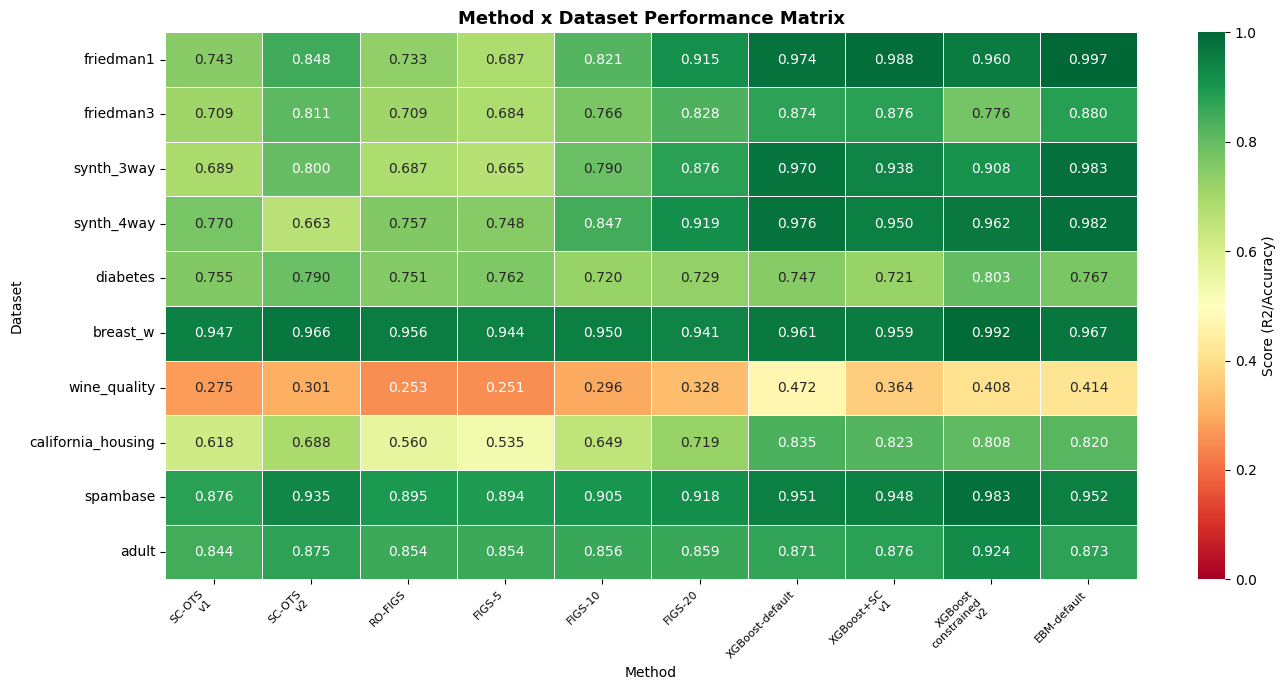

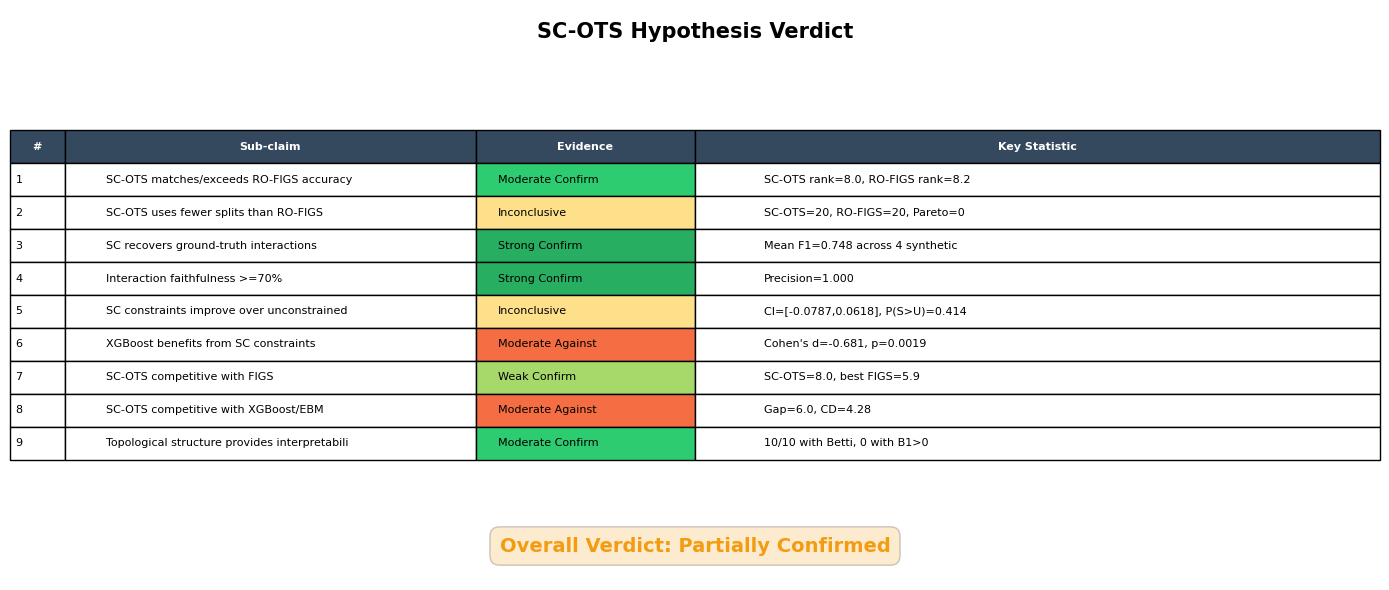

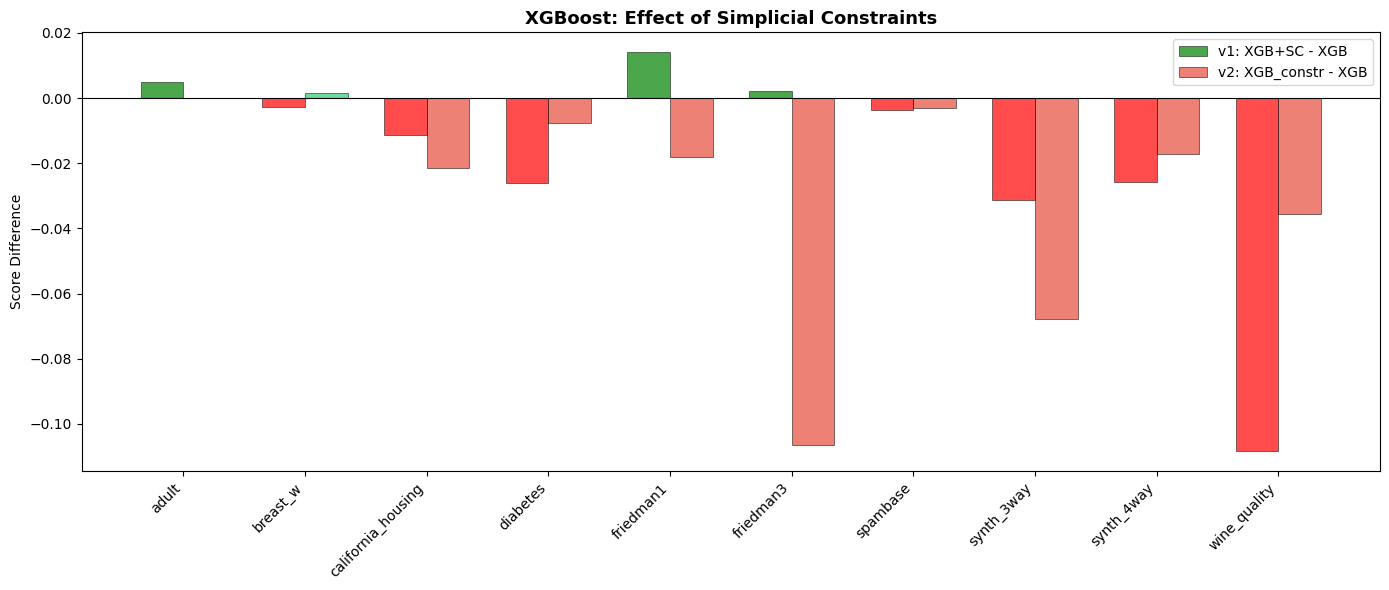

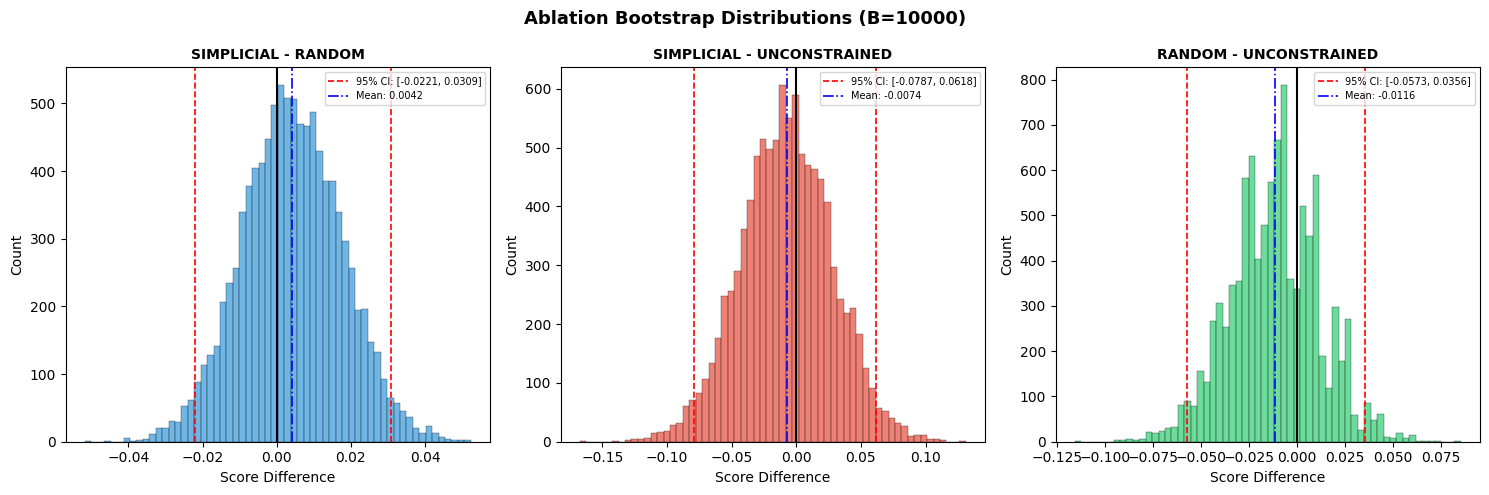


KEY METRICS SUMMARY
Friedman chi2 = 61.9418, p = 0.0
Critical Difference = 4.2836
Mean AUPRC (synthetic) = 0.4165
Faithfulness precision = 1.0
XGB+SC pooled Cohen's d = -0.6806
P(Simplicial > Unconstrained) = 0.4143
Verdict: Partially Confirmed (5/9 confirmed)


In [14]:
# ── Figure 1: Score Heatmap ──
score_mat = b1_result["unified_score_matrix"]
valid_methods = b1_result["valid_methods"]

heat_data = np.full((len(DATASETS_10), len(valid_methods)), np.nan)
for i, ds in enumerate(DATASETS_10):
    for j, m in enumerate(valid_methods):
        heat_data[i, j] = score_mat.get(ds, {}).get(m, np.nan)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heat_data, annot=True, fmt=".3f", cmap="RdYlGn",
    xticklabels=[m.replace("_", "\n") for m in valid_methods],
    yticklabels=DATASETS_10,
    ax=ax, vmin=0.0, vmax=1.0, linewidths=0.5,
    cbar_kws={"label": "Score (R2/Accuracy)"},
)
ax.set_title("Method x Dataset Performance Matrix", fontsize=13, fontweight="bold")
ax.set_xlabel("Method")
ax.set_ylabel("Dataset")
plt.xticks(rotation=45, ha="right", fontsize=8)
fig.tight_layout()
plt.show()

# ── Figure 2: Verdict Table ──
color_map = {
    "Strong Confirm": "#27ae60", "Moderate Confirm": "#2ecc71",
    "Weak Confirm": "#a6d96a", "Inconclusive": "#fee08b",
    "Weak Against": "#fdae61", "Moderate Against": "#f46d43",
    "Strong Against": "#d73027",
}

fig2, ax2 = plt.subplots(figsize=(14, 6))
ax2.axis("off")

headers = ["#", "Sub-claim", "Evidence", "Key Statistic"]
cell_text = []
cell_colors = []
for sc in b7_result["per_subclaim"]:
    row = [str(sc["id"]), sc["claim"][:45], sc["evidence_strength"], sc["key_statistic"][:50]]
    cell_text.append(row)
    bg = color_map.get(sc["evidence_strength"], "white")
    cell_colors.append(["white", "white", bg, "white"])

table = ax2.table(cellText=cell_text, colLabels=headers, cellColours=cell_colors,
                  colWidths=[0.04, 0.30, 0.16, 0.50], loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.6)
for j in range(len(headers)):
    cell = table[0, j]
    cell.set_facecolor("#34495e")
    cell.set_text_props(color="white", fontweight="bold")

verdict_color = {"Confirmed": "#27ae60", "Partially Confirmed": "#f39c12", "Disconfirmed": "#e74c3c"}
overall = b7_result["overall_verdict"]
ax2.text(0.5, 0.05, f"Overall Verdict: {overall}",
         transform=ax2.transAxes, ha="center", fontsize=14, fontweight="bold",
         color=verdict_color.get(overall, "black"),
         bbox=dict(boxstyle="round,pad=0.5", facecolor=verdict_color.get(overall, "gray"), alpha=0.2))
ax2.text(0.5, 0.95, "SC-OTS Hypothesis Verdict",
         transform=ax2.transAxes, ha="center", fontsize=15, fontweight="bold")
fig2.tight_layout()
plt.show()

# ── Figure 3: XGBoost Delta Bars ──
v1_ds = b4_result["v1_datasets"]
v1_diffs = b4_result["v1_diffs"]
v2_ds = b4_result["v2_datasets"]
v2_diffs = b4_result["v2_diffs"]

all_ds = sorted(set(v1_ds + v2_ds))
x = np.arange(len(all_ds))
width = 0.35
v1_map = dict(zip(v1_ds, v1_diffs))
v2_map = dict(zip(v2_ds, v2_diffs))

fig3, ax3 = plt.subplots(figsize=(14, 6))
v1_vals = [v1_map.get(ds, 0) for ds in all_ds]
v2_vals = [v2_map.get(ds, 0) for ds in all_ds]
colors_v1 = ["green" if v > 0 else "red" for v in v1_vals]
colors_v2 = ["#2ecc71" if v > 0 else "#e74c3c" for v in v2_vals]
ax3.bar(x - width/2, v1_vals, width, color=colors_v1, alpha=0.7, edgecolor="black", linewidth=0.5, label="v1: XGB+SC - XGB")
ax3.bar(x + width/2, v2_vals, width, color=colors_v2, alpha=0.7, edgecolor="black", linewidth=0.5, label="v2: XGB_constr - XGB")
ax3.axhline(y=0, color="black", linewidth=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(all_ds, rotation=45, ha="right")
ax3.set_ylabel("Score Difference")
ax3.set_title("XGBoost: Effect of Simplicial Constraints", fontsize=13, fontweight="bold")
ax3.legend()
fig3.tight_layout()
plt.show()

# ── Figure 4: Ablation Bootstrap ──
boot_sr = b5_result["boot_sr"]
boot_su = b5_result["boot_su"]
boot_ru = b5_result["boot_ru"]
ci_sr = b5_result["bootstrap_ci_95"]["simplicial_minus_random"]
ci_su = b5_result["bootstrap_ci_95"]["simplicial_minus_unconstrained"]
ci_ru = b5_result["bootstrap_ci_95"]["random_minus_unconstrained"]

fig4, axes = plt.subplots(1, 3, figsize=(15, 5))
data_labels = [
    (boot_sr, ci_sr, "SIMPLICIAL - RANDOM", "#3498db"),
    (boot_su, ci_su, "SIMPLICIAL - UNCONSTRAINED", "#e74c3c"),
    (boot_ru, ci_ru, "RANDOM - UNCONSTRAINED", "#2ecc71"),
]
for ax, (d, ci, label, color) in zip(axes, data_labels):
    ax.hist(d, bins=min(60, max(10, BOOTSTRAP_B // 5)), color=color, alpha=0.7, edgecolor="black", linewidth=0.3)
    ax.axvline(x=0, color="black", linewidth=1.5)
    ax.axvline(x=ci[0], color="red", linewidth=1.2, linestyle="--", label=f"95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")
    ax.axvline(x=ci[1], color="red", linewidth=1.2, linestyle="--")
    ax.axvline(x=np.mean(d), color="blue", linewidth=1.2, linestyle="-.", label=f"Mean: {np.mean(d):.4f}")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Score Difference")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)
fig4.suptitle(f"Ablation Bootstrap Distributions (B={BOOTSTRAP_B})", fontsize=13, fontweight="bold")
fig4.tight_layout()
plt.show()

# ── Print key metrics summary ──
print("\n" + "="*60)
print("KEY METRICS SUMMARY")
print("="*60)
print(f"Friedman chi2 = {b1_result['friedman_statistic']}, p = {b1_result['friedman_p_value']}")
print(f"Critical Difference = {b1_result['critical_difference']}")
print(f"Mean AUPRC (synthetic) = {b3_result['mean_auprc_synthetic']}")
print(f"Faithfulness precision = {b3_result['faithfulness_precision_mean']}")
print(f"XGB+SC pooled Cohen's d = {b4_result['pooled']['cohens_d']}")
print(f"P(Simplicial > Unconstrained) = {b5_result['p_simplicial_gt_unconstrained']}")
print(f"Verdict: {b7_result['overall_verdict']} ({b7_result['confirm_count']}/9 confirmed)")
print("="*60)